In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations

In [3]:
df = pd.read_csv('dissertation/full_image_data_feb_25.csv')

In [5]:
print(df.columns)

Index(['images', 'cluster_name', 'cks', 'book', 'bid', 'part_or_adaption',
       'part_or_adaption_label', 'type_label', 'custom_identifier', 'place',
       'year', 'flag', 'year_interval', 'place_category', 'latitude',
       'longitude', 'part_type'],
      dtype='object')


In [6]:
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')


In [7]:
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# Haversine distance (in km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

# For each cluster, find the max distance between any two locations
def max_cluster_distance(cluster_df):
    coords = cluster_df[['latitude', 'longitude']].dropna().values
    if len(coords) < 2:
        return 0  # Only one or zero locations
    max_dist = 0
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            dist = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
            if dist > max_dist:
                max_dist = dist
    return max_dist

# Apply per cluster_name
cluster_spread = (
    df.groupby('cluster_name')
      .apply(max_cluster_distance)
      .reset_index(name='max_distance_km')
      .sort_values('max_distance_km', ascending=False)
)

print(cluster_spread.head(10))


       cluster_name  max_distance_km
366   SAC_SIL_00376     10040.243261
3380  SAC_SIL_03669      2612.711253
1785  SAC_SIL_01864      2612.711253
951   SAC_SIL_00975      2612.711253
3428  SAC_SIL_03719      2612.711253
1795  SAC_SIL_01875      2498.439791
1581  SAC_SIL_01641      2299.126626
1848  SAC_SIL_01935      2230.556260
1883  SAC_SIL_01971      2230.556260
1411  SAC_SIL_01449      2230.556260


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_73162/555422024.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(max_cluster_distance)


In [8]:
top_cluster = cluster_spread.iloc[0]['cluster_name']
print("Most geographically distant cluster:", top_cluster)

print(df[df['cluster_name'] == top_cluster][['place', 'latitude', 'longitude']])


Most geographically distant cluster: SAC_SIL_00376
             place   latitude  longitude
11713       Venice  45.437191  12.334590
11714       Venice  45.437191  12.334590
11715       Venice  45.437191  12.334590
11716       Venice  45.437191  12.334590
21006  Mexico City  19.432630 -99.133178
21007  Mexico City  19.432630 -99.133178
21008  Mexico City  19.432630 -99.133178
21009  Mexico City  19.432630 -99.133178


In [11]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# 1. Make sure coordinates are numeric
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# 2. Define the Haversine distance function (in kilometers)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius (km)
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

# 3. Function to compute the max distance *within each cluster*
def cluster_max_distance(group):
    coords = group[['latitude', 'longitude']].dropna().values
    n = len(coords)
    if n < 2:
        return 0
    max_dist = 0
    for i in range(n):
        for j in range(i + 1, n):
            dist = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
            if dist > max_dist:
                max_dist = dist
    return max_dist

# 4. Apply per cluster_name (safe for pandas 2.2+)
try:
    cluster_distances = (
        df.groupby('cluster_name', group_keys=False, include_groups=False)
          .apply(cluster_max_distance)
          .reset_index(name='max_distance_km')
          .sort_values('max_distance_km', ascending=False)
    )
except TypeError:
    # fallback for older pandas (include_groups not supported)
    cluster_distances = (
        df[['cluster_name', 'latitude', 'longitude']]
          .groupby('cluster_name', group_keys=False)
          .apply(cluster_max_distance)
          .reset_index(name='max_distance_km')
          .sort_values('max_distance_km', ascending=False)
    )

# 5. Display the result
print(cluster_distances.head(10))

# 6. (Optional) Inspect the most geographically distant cluster
top_cluster = cluster_distances.iloc[0]['cluster_name']
print(f"\nMost geographically distant cluster: {top_cluster}\n")
print(df[df['cluster_name'] == top_cluster][['place', 'latitude', 'longitude']])


       cluster_name  max_distance_km
366   SAC_SIL_00376     10040.243261
3380  SAC_SIL_03669      2612.711253
1785  SAC_SIL_01864      2612.711253
951   SAC_SIL_00975      2612.711253
3428  SAC_SIL_03719      2612.711253
1795  SAC_SIL_01875      2498.439791
1581  SAC_SIL_01641      2299.126626
1848  SAC_SIL_01935      2230.556260
1883  SAC_SIL_01971      2230.556260
1411  SAC_SIL_01449      2230.556260

Most geographically distant cluster: SAC_SIL_00376

             place   latitude  longitude
11713       Venice  45.437191  12.334590
11714       Venice  45.437191  12.334590
11715       Venice  45.437191  12.334590
11716       Venice  45.437191  12.334590
21006  Mexico City  19.432630 -99.133178
21007  Mexico City  19.432630 -99.133178
21008  Mexico City  19.432630 -99.133178
21009  Mexico City  19.432630 -99.133178


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_73162/216579825.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cluster_max_distance)


In [12]:
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

# 1. Ensure coordinates are numeric
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# 2. Haversine distance function (km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1-a))

# 3. Compute max distance within a group
def max_distance(group):
    coords = group[['latitude','longitude']].dropna().values
    n = len(coords)
    if n < 2:
        return 0
    max_dist = 0
    for i in range(n):
        for j in range(i+1, n):
            dist = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
            if dist > max_dist:
                max_dist = dist
    return max_dist

# 4. Apply per 'cks'
try:
    cks_distances = (
        df.groupby('cks', group_keys=False, include_groups=False)
          .apply(max_distance)
          .reset_index(name='max_distance_km')
          .sort_values('max_distance_km', ascending=False)
    )
except TypeError:
    # fallback for older pandas
    cks_distances = (
        df[['cks','latitude','longitude']]
          .groupby('cks', group_keys=False)
          .apply(max_distance)
          .reset_index(name='max_distance_km')
          .sort_values('max_distance_km', ascending=False)
    )

# 5. Show top 10 most distant cks
print("Top 10 most geographically distant cks values:")
print(cks_distances.head(10))

# 6. Inspect the most distant cks
top_cks = cks_distances.iloc[0]['cks']
print(f"\nMost geographically distant cks: {top_cks}")
print(df[df['cks'] == top_cks][['place','latitude','longitude']])


Top 10 most geographically distant cks values:
                                        cks  max_distance_km
25   CK_Circles of Equant Deferent Epicycle     10260.904285
137                            CK_Sun Orbit     10260.904285
68                           CK_Lunar Orbit     10151.312832
144               CK_Superior Planets Orbit     10040.243261
159                          CK_Venus Orbit     10040.243261
59                               CK_Horizon      2612.711253
26               CK_Circles of Natural Days      2612.711253
134      CK_Structure of the Sublunar World      2612.711253
42        CK_Definition of Sphere by Euclid      2612.711253
43    CK_Definition of Sphere by Theodosius      2612.711253

Most geographically distant cks: CK_Circles of Equant Deferent Epicycle
         place   latitude  longitude
2       Venice  45.437191  12.334590
3       Venice  45.437191  12.334590
71      Venice  45.437191  12.334590
99      Venice  45.437191  12.334590
140     Venice  45.43719

/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_73162/335314388.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(max_distance)


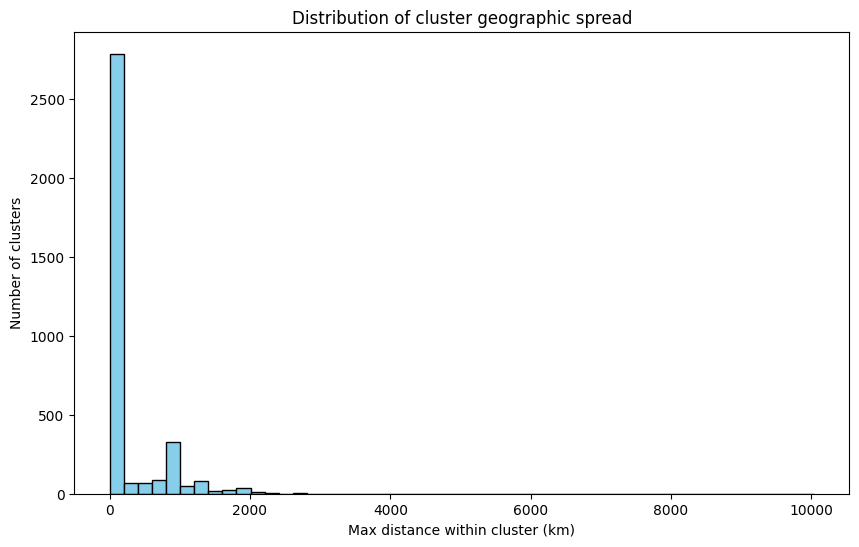

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(cluster_distances['max_distance_km'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Max distance within cluster (km)')
plt.ylabel('Number of clusters')
plt.title('Distribution of cluster geographic spread')
plt.show()


In [15]:
# Count number of images per cluster
cluster_sizes = df.groupby('cluster_name').size().reset_index(name='num_images')

# Merge with cluster_distances
cluster_distances_full = cluster_distances.merge(cluster_sizes, on='cluster_name')


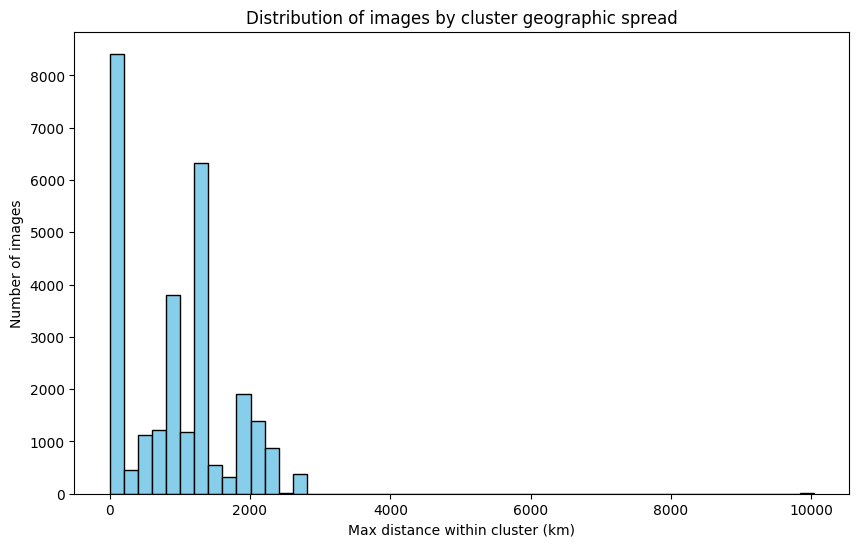

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Use 'num_images' as weights so each image counts instead of each cluster
plt.hist(
    cluster_distances_full['max_distance_km'],
    bins=50,
    weights=cluster_distances_full['num_images'],
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Max distance within cluster (km)')
plt.ylabel('Number of images')
plt.title('Distribution of images by cluster geographic spread')
plt.show()
